# Exploring the simulated data

This notebook walks through the **molecular data** iscc produces, one modality at a time: bulk DNA,
single-cell DNA, single-cell RNA (with scanpy), and Visium spatial transcriptomics (with squidpy).

We grow one tumour and **resect it** — the whole growth is the specimen — then sample it with two kinds
of cut. An **in-plane cut** takes a 2-D part for the sequencing assays (dissociated, so spatial position
is lost). A **depth cut** takes a thin slice of the remainder — the full 2-D field but only part of each
deme's 3-D column — which is the Visium section. Because iscc knows the **true cell type** of every
cell, we can check the unsupervised clusters/niches against the ground truth. Each cell below runs one
iscc tool and plots its output.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import squidpy as sq
from collections import Counter
from iscc.constants import normal_names
from iscc.tumor.models import GenotypeTumor
from iscc.sample import Resection
from iscc.data import bulkDNA, scDNA, scRNA, Visium

sc.settings.verbosity = 0
CONFIG = os.path.join(os.getcwd(), "example_config.yaml")

def coarse_type(v):                      # collapse a per-cell label to cancer / normal type
    return v if v in normal_names else "cancer"

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Grow and resect the tumour

Grow one cm-scale tumour (~8.5 mm, ~10⁶ cells) and resect it — the whole growth is the **specimen**.
Its ground-truth tissue map (built from the per-deme counts) shows a single clonal founder growing as
DCIS in the ducts with focal invasion (IDC) into the stroma. Growing takes ~3 min.

specimen: 323342 cancer / 588938 total cells across 28900 demes (170 x 170 ~ 8.5 mm)


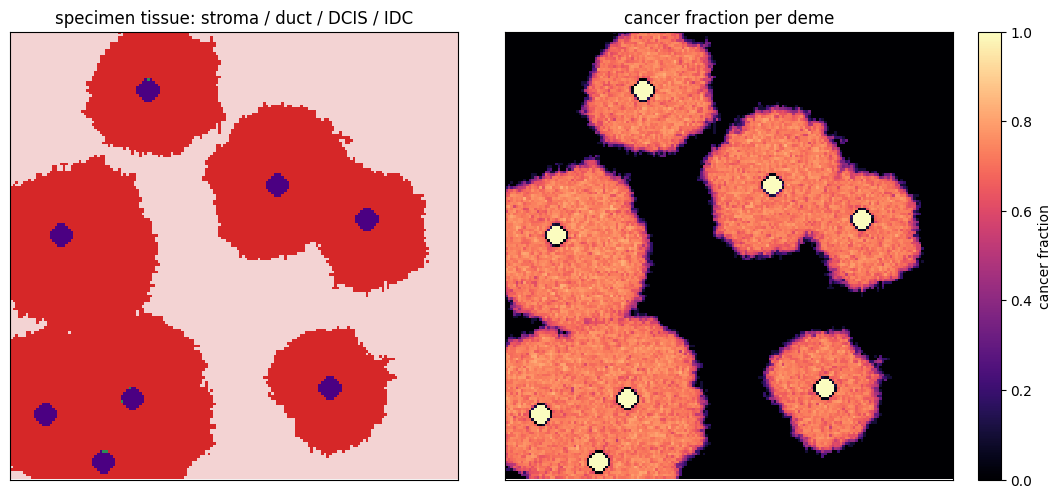

In [2]:
tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=150, seed=2)
print(f"specimen: {tumor.get_cancer_size()} cancer / {tumor.get_tumor_size()} total cells "
      f"across {len(tumor.demes)} demes ({tumor.grid_size} x {tumor.grid_size} ~ 8.5 mm)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
tumor.plot_tissue(ax=axes[0], color="state")
axes[0].set_title("specimen tissue: stroma / duct / DCIS / IDC")
tumor.plot_tissue(ax=axes[1], color="cancer_frac")
axes[1].set_title("cancer fraction per deme")
plt.tight_layout()

## Cutting the specimen

We sample the specimen with two orthogonal cuts (`iscc.sample.Resection`). An **in-plane cut**
(`bisect`) splits the 2-D tissue: one part is dissociated for the sequencing assays, the remainder is
kept for the Visium section. (The **depth cut** for Visium comes later.) `Resection` materialises only
each piece, so this stays memory-safe at cm-scale.

in-plane cut: 12070 demes dissociated | 16830 demes kept for imaging


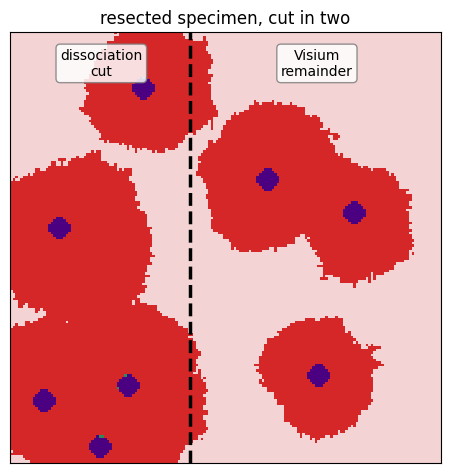

In [3]:
spec = Resection(tumor)
CUT_FRAC = 0.42
cut, remainder = spec.bisect(frac=CUT_FRAC, axis="x")   # in-plane cut: dissociation | imaging
split = int(CUT_FRAC * tumor.grid_size)

fig, ax = plt.subplots(figsize=(5.6, 5.6))
tumor.plot_tissue(ax=ax, color="state")
ax.axvline(split - 0.5, color="k", lw=2.5, ls="--")
box = dict(boxstyle="round", fc="white", ec="0.5", alpha=0.85)
ax.text(split * 0.5, 6, "dissociation\ncut", ha="center", va="top", bbox=box)
ax.text((split + tumor.grid_size) * 0.5, 6, "Visium\nremainder", ha="center", va="top", bbox=box)
ax.set_title("resected specimen, cut in two")
print(f"in-plane cut: {len(cut)} demes dissociated | {len(remainder)} demes kept for imaging")

## The dissociated sample and its ground truth

Dissociate the cut into a per-cell table — the sample the sequencing assays sequence. Because iscc
simulated every cell, it knows the ground truth: each cell's true type, clone, copy number and SNVs.
Here is the true SNV matrix of the dissociated cells (the assays below are noisy views of it).

dissociated 50304 cells (32339 cancer, 17965 microenvironment) | 600 genes, 10 oncogenes, 8 tumour suppressors


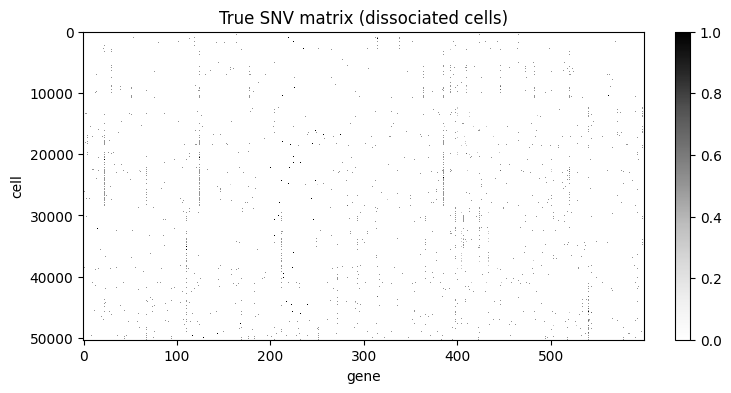

In [4]:
cd = spec.dissociate(cut, max_cells=50000)          # dissociate the cut -> the sequencing sample
true_type = cd["cell_type"]["cell_id"].astype(str)  # ground-truth cell type per cell
drivers = tumor.get_gene_data()["driver_types"].iloc[:, 0]   # +1 oncogene, -1 TSG, 0 passenger
n_can = int(cd["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").sum())
print(f"dissociated {len(cd['cell_snv'])} cells ({n_can} cancer, {len(cd['cell_snv']) - n_can} "
      f"microenvironment) | {len(drivers)} genes, {int((drivers == 1).sum())} oncogenes, "
      f"{int((drivers == -1).sum())} tumour suppressors")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(cd["cell_snv"].values, aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("gene"); ax.set_ylabel("cell"); ax.set_title("True SNV matrix (dissociated cells)")
plt.colorbar(im, ax=ax, fraction=0.046)

## Bulk DNA-seq

Bulk DNA pools the dissociated cells into one library: per-gene coverage and alt-read counts, from
which we read a variant-allele-frequency (VAF) spectrum.

top variant genes: ['G_4_12', 'G_7_35', 'G_7_43', 'G_11_4', 'G_1_2']


Text(0.5, 1.0, 'Bulk DNA VAF spectrum')

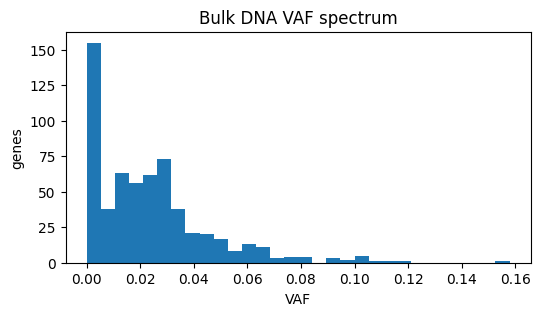

In [5]:
bd = bulkDNA(n_reads=50000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(cd)
vaf = bd.observed_data["vaf"][bd.observed_data["coverage"] > 0]   # drop zero-coverage loci
print("top variant genes:", list(vaf.sort_values(ascending=False).head(5).index))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30); ax.set_xlabel("VAF"); ax.set_ylabel("genes")
ax.set_title("Bulk DNA VAF spectrum")

## Single-cell DNA-seq

scDNA resolves SNVs per cell. We compute a per-cell VAF matrix (alt / coverage) — the substrate for
clone reconstruction.

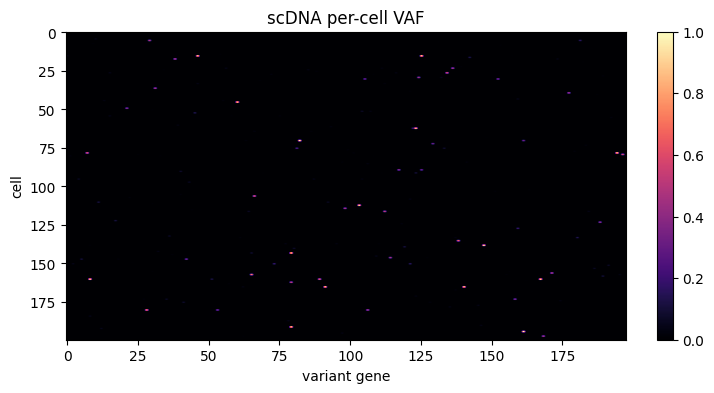

In [6]:
sd = scDNA(n_cells=200, breadth="wgs")
sd.run(cd)
sc_vaf = sd.vaf.fillna(0)
keep = sc_vaf.columns[sc_vaf.sum(0) > 0]   # genes with any signal

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(sc_vaf[keep].values, aspect="auto", cmap="magma")
ax.set_xlabel("variant gene"); ax.set_ylabel("cell"); ax.set_title("scDNA per-cell VAF")
plt.colorbar(im, ax=ax, fraction=0.046)

## Single-cell RNA-seq

scRNA gives UMI counts per cell. We turn the assay into an `AnnData`, **annotate each cell with its true
type**, then run a standard scanpy workflow (QC, normalization, PCA, neighbours, Leiden, UMAP) — and
colour the UMAP by the true cell type to see how well the unsupervised clusters recover it.

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cell-type annotations: {'cancer': 247, 'stromal': 145, 'epithelial': 8}


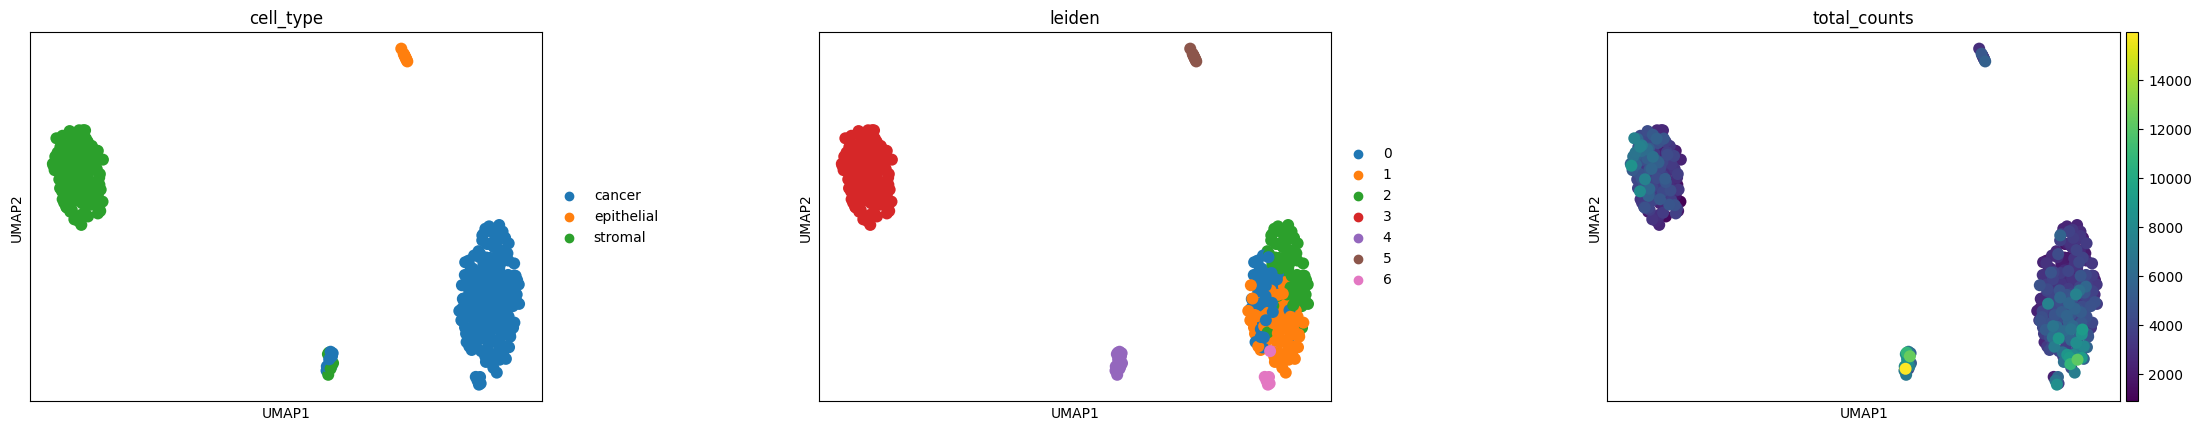

In [7]:
sr = scRNA(n_reads=4000, n_cells=400)
sr.run(cd)
adata = sr.to_anndata()
adata.obs["cell_type"] = pd.Categorical(true_type.reindex(adata.obs_names).map(coarse_type))
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata)
print("cell-type annotations:", dict(adata.obs["cell_type"].value_counts()))

sc.pl.umap(adata, color=["cell_type", "leiden", "total_counts"], wspace=0.4)

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:446: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin, ymax)


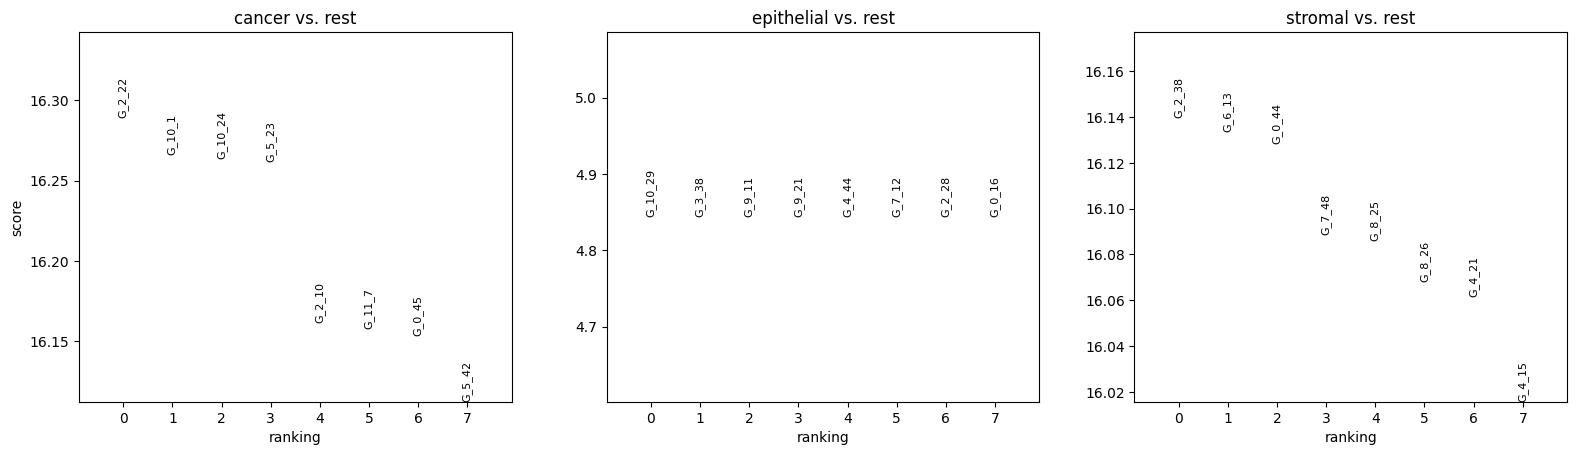

In [8]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=8, sharey=False)

## Visium spatial transcriptomics

Visium is a **spatial** assay. From the imaging **remainder** we take a **depth cut** (`spec.slice(remainder, depth_frac=0.5)`) — a thin section keeping the whole 2-D field but only half of each deme's 3-D column. First the **H&E of the whole remainder** (the tissue we image):

section: 119780 cells over 16783 demes


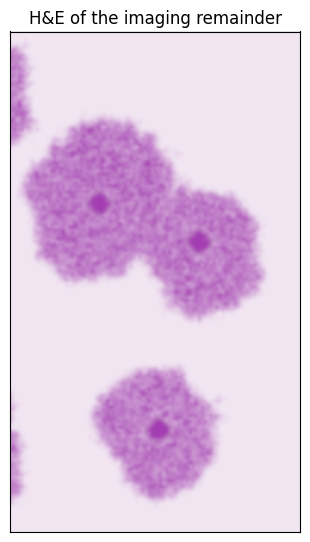

In [9]:
section = spec.slice(remainder, depth_frac=0.5, max_cells=120000)   # depth cut -> thin section

# H&E of the whole imaging remainder (dense nuclei = invasive masses; pale = stroma):
he, px = tumor.he_image(px=6)
fig, ax = plt.subplots(figsize=(5.5, 6.5))
ax.imshow(he[:, int(CUT_FRAC * tumor.grid_size * px):])            # crop to the remainder (right of cut)
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("H&E of the imaging remainder")
print(f"section: {len(section['cell_snv'])} cells over {len(set(section['cell_deme']['deme_id']))} demes")

The remainder is **tall** and the v1 slide is **wide**, so we **rotate** the section 90° to capture more, and **place** the slide on the lesion. `vz.place_grid(section)` positions the fixed grid *without* assaying it, so we can plot the spot grid on the H&E (via `to_anndata`, no data yet) and check the placement first:

placed the slide (rotated 90 deg) on the lesion -> 4396/4992 spots in-tissue


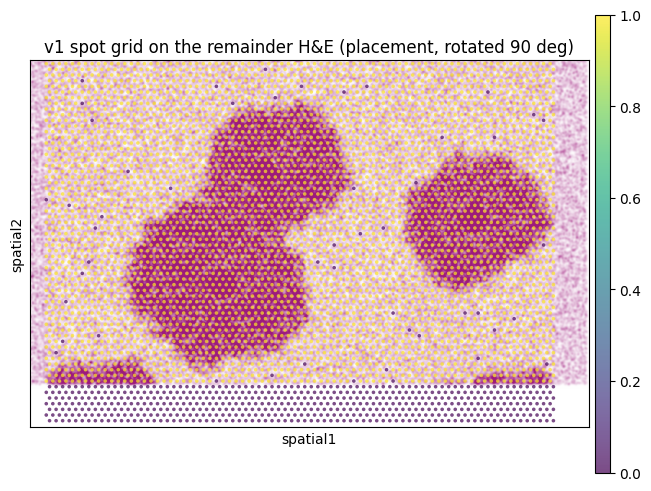

In [10]:
canc = section["cell_type"]["cell_id"].map(lambda g: tumor.genotypes[g].type == "cancer").values
pc = section["cell_crd"][["row", "col"]].to_numpy(float)[canc]
placement = (float(pc[:, 0].mean()), float(pc[:, 1].mean()))
vz = Visium(n_reads=20000, spot_pitch=2.0, spot_radius=0.55, section_frac=1.0,
            placement=placement, rotation=90, seed=0)
vz.place_grid(section)
grid = vz.to_anndata()                            # spot grid + full H&E, X all zero (placement only)
lib = list(grid.uns["spatial"])[0]
sq.pl.spatial_scatter(grid, color="in_tissue", library_id=lib, img=True, shape="circle", size=1.0,
                      alpha=0.7, title="v1 spot grid on the remainder H&E (placement, rotated 90 deg)")
print(f"placed the slide (rotated 90 deg) on the lesion -> "
      f"{int((grid.obs['in_tissue'] == 1).sum())}/{grid.n_obs} spots in-tissue")

Now **run** the assay over the placed grid (`vz.run()` reuses the placement) and analyse the spots with **squidpy** and **scanpy** exactly as we would a real Visium slide.

Visium: 4396 in-tissue spots | median 5 cells/spot | 4 spatial niches


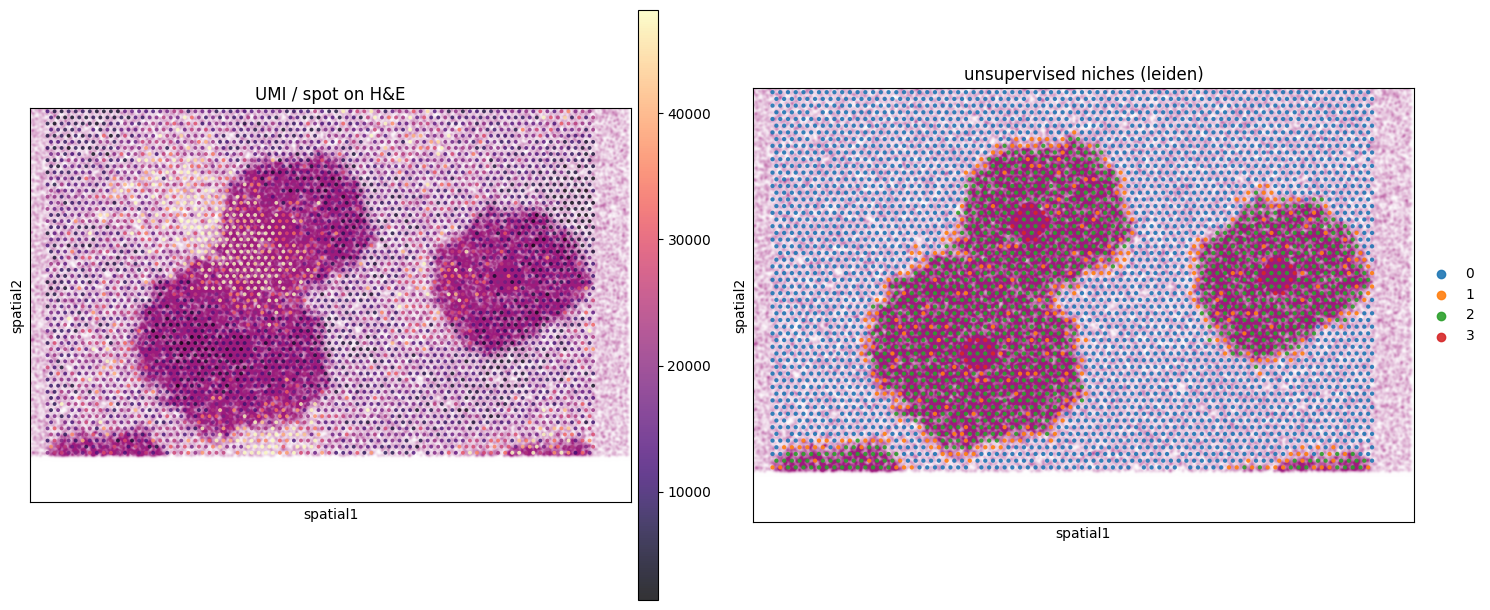

In [11]:
vz.run()                                          # reuse the placed grid, now assay it
vis = vz.to_anndata()
vis = vis[vis.obs["in_tissue"] == 1].copy()          # keep the in-tissue spots
sc.pp.calculate_qc_metrics(vis, inplace=True, percent_top=None)
sc.pp.normalize_total(vis); sc.pp.log1p(vis)
sc.pp.pca(vis, n_comps=20); sc.pp.neighbors(vis)
sc.tl.leiden(vis, resolution=0.8, flavor="igraph", n_iterations=2, directed=False)
print(f"Visium: {vis.n_obs} in-tissue spots | median {int(np.median(vis.obs['n_cells']))} cells/spot "
      f"| {vis.obs['leiden'].nunique()} spatial niches")

# squidpy draws the spots straight onto the assay's own H&E image (img=True).
umi_vmax = float(np.percentile(vis.obs["total_counts"], 95))
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
sq.pl.spatial_scatter(vis, color="total_counts", library_id=lib, ax=axes[0], fig=fig, img=True,
                      shape="circle", size=1.0, alpha=0.8, vmax=umi_vmax, cmap="magma",
                      title="UMI / spot on H&E")
sq.pl.spatial_scatter(vis, color="leiden", library_id=lib, ax=axes[1], fig=fig, img=True,
                      shape="circle", size=1.0, alpha=0.9, title="unsupervised niches (leiden)")
plt.tight_layout()

## Recap

From **one resected tumour** we sampled two ways: an **in-plane cut**, dissociated for bulk DNA / scDNA /
scRNA; and a thin **depth-slice** of the remainder, imaged with Visium. Each is a noisy, partial
measurement of the same ground truth, analysed with the same off-the-shelf tools (scanpy, squidpy) you
would use on real data — yet iscc knows the ground truth (each cell's true type, clone, copy number and
mutations), so these datasets are ideal benchmarks for tumour-evolution methods.

The assays model realistic technical structure — negative-binomial + dropout scRNA, allele-specific
single-cell DNA with allelic dropout, a read/FASTQ mode, and spatial spot mixing with autocorrelation —
and their parameters can be fit to real reference data. Further analysis-demo notebooks (MHN from DNA,
niche identification, batch effects, combining modalities, real-data comparison) build on these
datasets.